In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sentiment = pd.read_csv("../data/fear_greed_index.csv")
trades = pd.read_csv("../data/historical_data.csv")

In [3]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)


In [6]:
print(sentiment.columns)
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='str')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')


In [7]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [8]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [9]:
print(sentiment.isnull().sum())
print(trades.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [10]:
print("Sentiment duplicates:", sentiment.duplicated().sum())
print("Trades duplicates:", trades.duplicated().sum())

Sentiment duplicates: 0
Trades duplicates: 0


In [11]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['date'].head()

0   2018-02-01
1   2018-02-02
2   2018-02-03
3   2018-02-04
4   2018-02-05
Name: date, dtype: datetime64[us]

In [12]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
)

trades['date'] = trades['Timestamp IST'].dt.date
trades['date'] = pd.to_datetime(trades['date'])

trades[['Timestamp IST', 'date']].head()

,Timestamp IST,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [13]:
print(sentiment['date'].min())
print(sentiment['date'].max())

print(trades['date'].min())
print(trades['date'].max())

2018-02-01 00:00:00
2025-05-02 00:00:00
2023-05-01 00:00:00
2025-05-01 00:00:00


In [14]:
print("Sentiment:")
print(sentiment['date'].min())
print(sentiment['date'].max())

print("\nTrades:")
print(trades['date'].min())
print(trades['date'].max())

Sentiment:
2018-02-01 00:00:00
2025-05-02 00:00:00

Trades:
2023-05-01 00:00:00
2025-05-01 00:00:00


In [15]:
df = pd.merge(
    trades,
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [16]:
print(df.shape)
df[['date', 'classification']].head()

(211224, 18)


,date,classification
0,2024-12-02,Extreme Greed
1,2024-12-02,Extreme Greed
2,2024-12-02,Extreme Greed
3,2024-12-02,Extreme Greed
4,2024-12-02,Extreme Greed


In [17]:
df['classification'].isnull().sum()

np.int64(6)

In [18]:
df['classification'].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

In [19]:
df['win'] = np.where(
    df['Closed PnL'] > 0,
    1,
    0
)

df[['Closed PnL', 'win']].head()

,Closed PnL,win
0,0.0,0
1,0.0,0
2,0.0,0
3,0.0,0
4,0.0,0


In [20]:
df.groupby(
    'classification'
)['Closed PnL'].mean()

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

In [21]:
(
    df.groupby('classification')['win']
      .mean()
      * 100
)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: win, dtype: float64

In [22]:
df.groupby(
    'classification'
).size()

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64

In [23]:
df = df.dropna(subset=['classification'])

In [24]:
df['classification'].isnull().sum()

np.int64(0)

In [25]:
df.groupby(
    'classification'
)['Closed PnL'].mean().sort_values(
    ascending=False
)

classification
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Extreme Fear     34.537862
Neutral          34.307718
Name: Closed PnL, dtype: float64

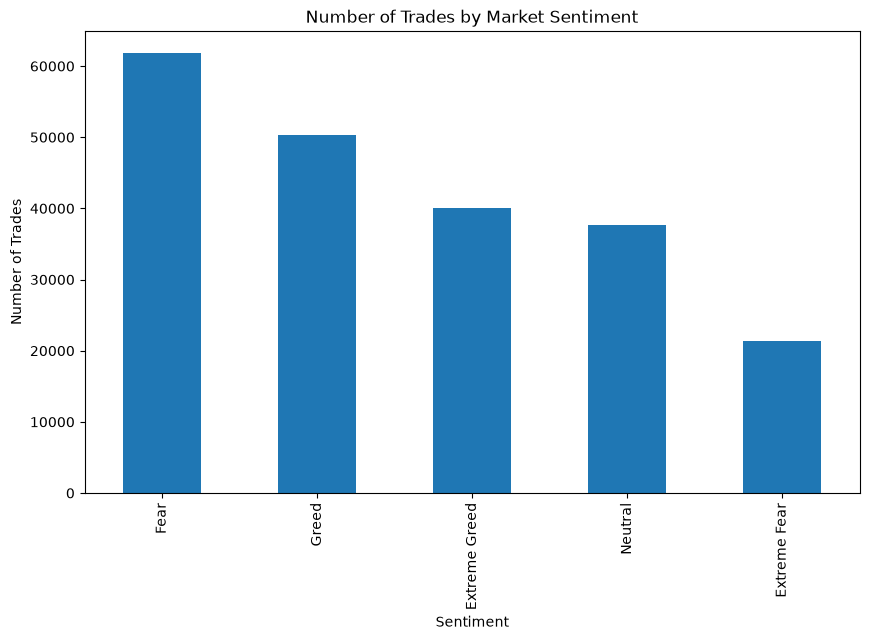

<Figure size 640x480 with 0 Axes>

In [29]:
plt.figure(figsize=(10,6))

df['classification'].value_counts().plot(
    kind='bar'
)

plt.title(
    'Number of Trades by Market Sentiment'
)
plt.xlabel('Sentiment')
plt.ylabel('Number of Trades')

plt.show()
plt.savefig(
    '../charts/win_rate.png'
)

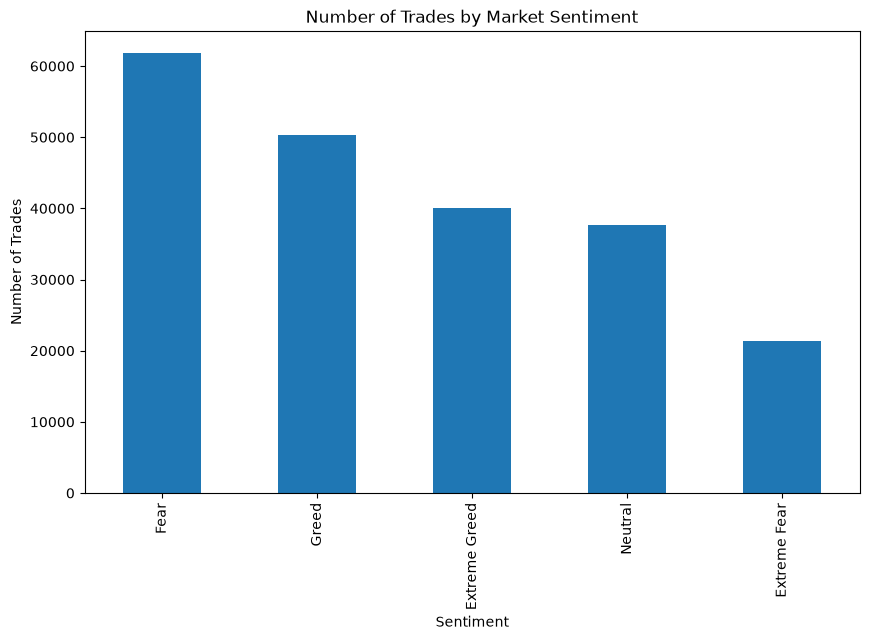

<Figure size 640x480 with 0 Axes>

In [30]:
plt.figure(figsize=(10,6))

df['classification'].value_counts().plot(
    kind='bar'
)

plt.title(
    'Number of Trades by Market Sentiment'
)
plt.xlabel('Sentiment')
plt.ylabel('Number of Trades')

plt.show()
plt.savefig(
    '../charts/trades_by_sentiment.png'
)


In [31]:
df.groupby(
    'classification'
)['Closed PnL'].mean().sort_values(
    ascending=False
)

classification
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Extreme Fear     34.537862
Neutral          34.307718
Name: Closed PnL, dtype: float64

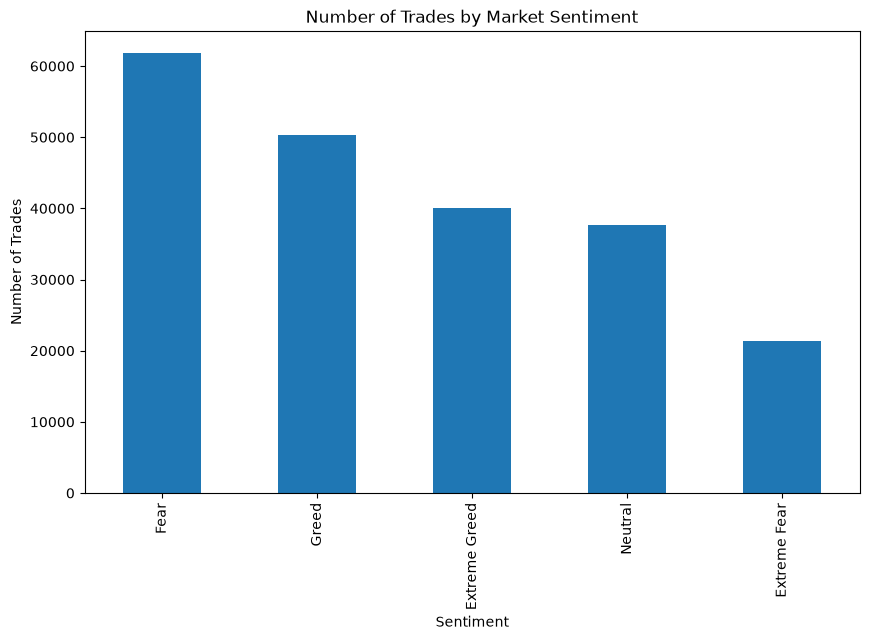

In [32]:
# Chart 1
plt.figure(figsize=(10,6))
df['classification'].value_counts().plot(kind='bar')
plt.title('Number of Trades by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Trades')
plt.show()

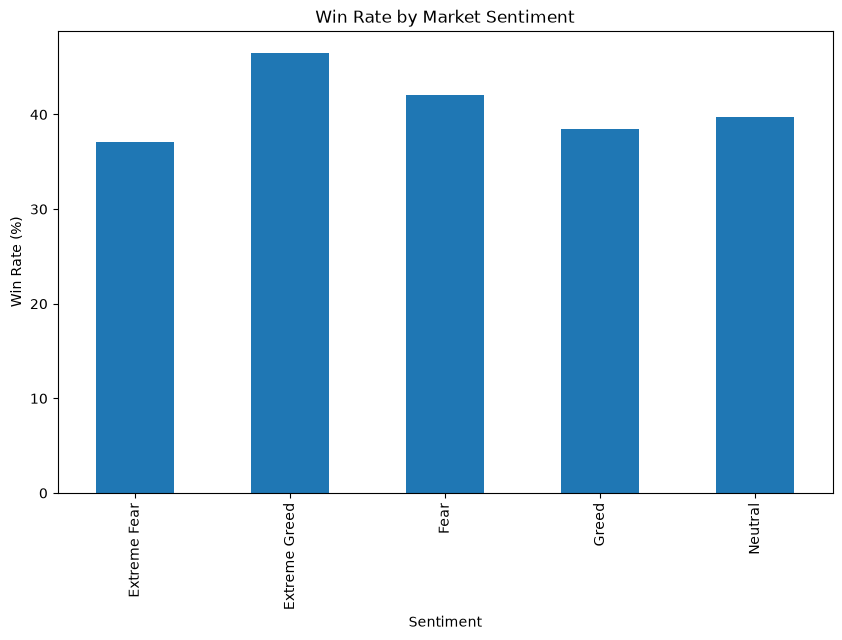

In [33]:
# Chart 2
win_rate = (
    df.groupby('classification')['win']
      .mean()
      * 100
)

plt.figure(figsize=(10,6))
win_rate.plot(kind='bar')
plt.title('Win Rate by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Win Rate (%)')
plt.show()

In [34]:
trade_size = (
    df.groupby('classification')
      ['Size USD']
      .mean()
      .sort_values(ascending=False)
)

trade_size

classification
Fear             7816.109931
Greed            5736.884375
Extreme Fear     5349.731843
Neutral          4782.732661
Extreme Greed    3112.251565
Name: Size USD, dtype: float64

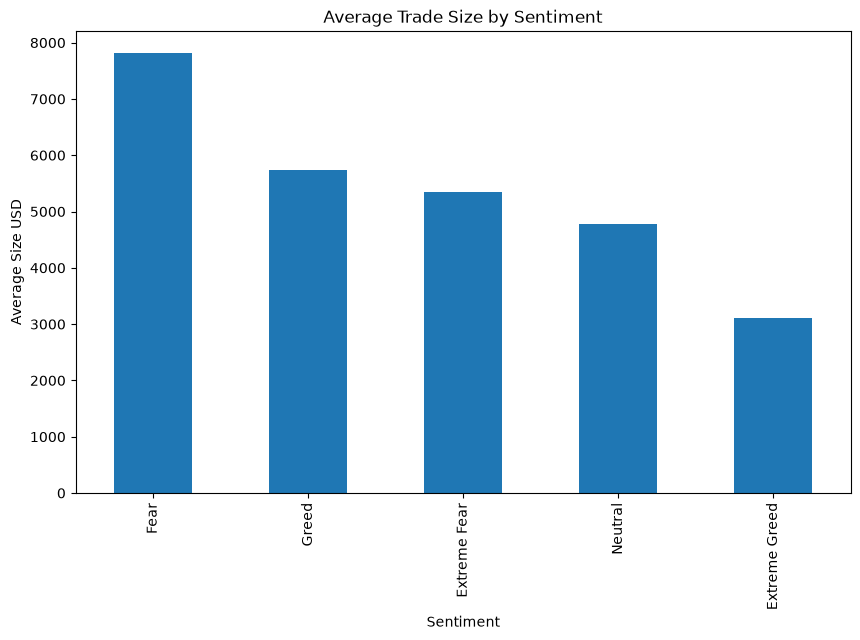

In [35]:
plt.figure(figsize=(10,6))

trade_size.plot(kind='bar')

plt.title(
    'Average Trade Size by Sentiment'
)
plt.xlabel('Sentiment')
plt.ylabel('Average Size USD')

plt.show()

In [36]:
df['Side'].value_counts()

Side
SELL    108528
BUY     102690
Name: count, dtype: int64

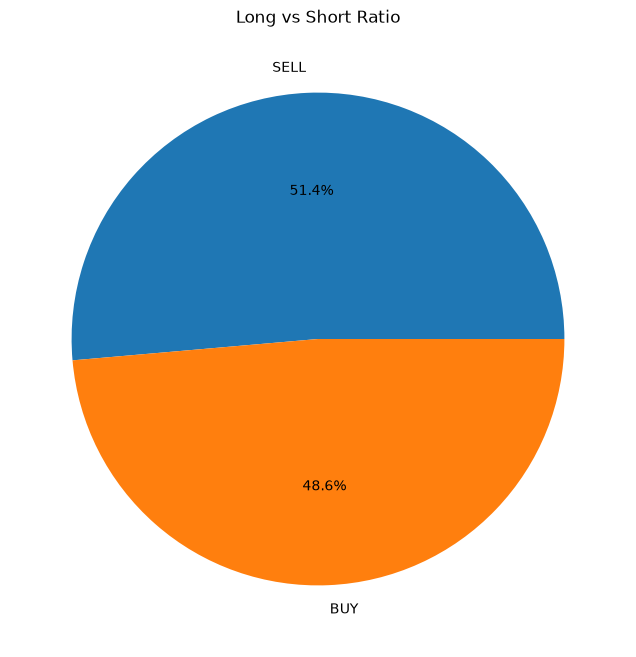

In [37]:
plt.figure(figsize=(8,8))

df['Side'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title(
    'Long vs Short Ratio'
)

plt.ylabel('')

plt.show()

In [38]:
df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'classification', 'win'],
      dtype='str')

In [39]:
df['Leverage'].describe()

KeyError: 'Leverage'

In [40]:
for col in df.columns:
    print(col)

Account
Coin
Execution Price
Size Tokens
Size USD
Side
Timestamp IST
Start Position
Direction
Closed PnL
Transaction Hash
Order ID
Crossed
Fee
Trade ID
Timestamp
date
classification
win


In [41]:
trade_size = (
    df.groupby('classification')['Size USD']
      .mean()
      .sort_values(ascending=False)
)

trade_size

classification
Fear             7816.109931
Greed            5736.884375
Extreme Fear     5349.731843
Neutral          4782.732661
Extreme Greed    3112.251565
Name: Size USD, dtype: float64

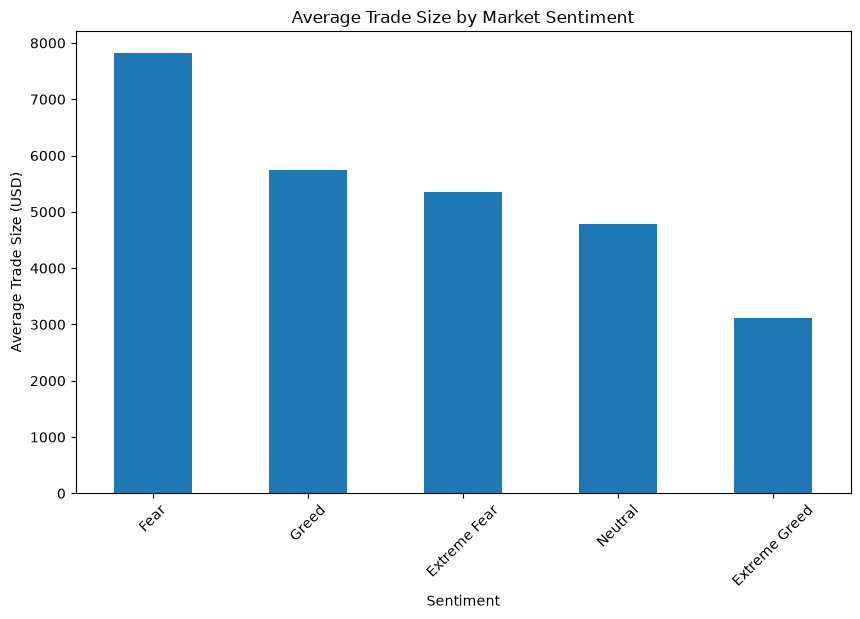

In [42]:
plt.figure(figsize=(10,6))

trade_size.plot(kind='bar')

plt.title('Average Trade Size by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Trade Size (USD)')
plt.xticks(rotation=45)

plt.show()

In [43]:
df['Side'].value_counts()

Side
SELL    108528
BUY     102690
Name: count, dtype: int64

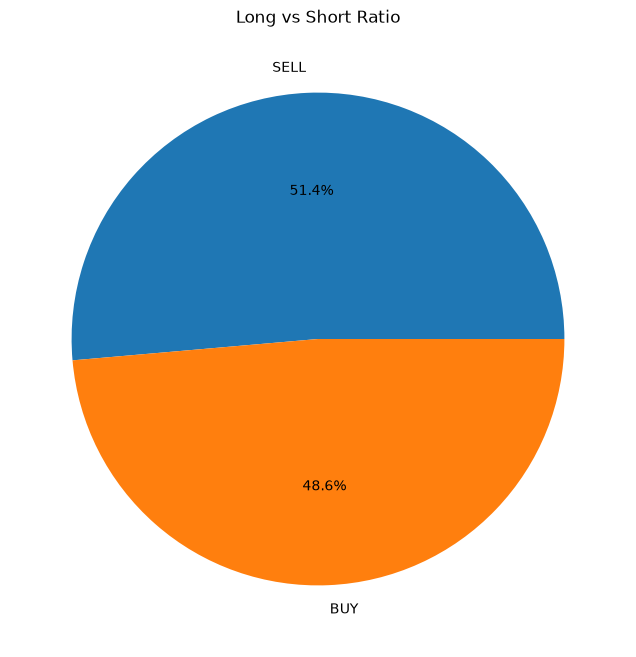

In [44]:
plt.figure(figsize=(8,8))

df['Side'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Long vs Short Ratio')
plt.ylabel('')

plt.show()

In [45]:
trades_per_account = (
    df.groupby('Account')
      .size()
      .reset_index(name='trade_count')
)

trades_per_account.head()

,Account,trade_count
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280
2,0x271b280974205ca63b716753467d5a371de622ab,3809
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239


In [46]:
median_trades = trades_per_account['trade_count'].median()

trades_per_account['segment'] = np.where(
    trades_per_account['trade_count'] >= median_trades,
    'Frequent Trader',
    'Infrequent Trader'
)

trades_per_account['segment'].value_counts()

segment
Frequent Trader      16
Infrequent Trader    16
Name: count, dtype: int64

In [47]:
pnl_per_account = (
    df.groupby('Account')['Closed PnL']
      .mean()
      .reset_index()
)

pnl_per_account['segment'] = np.where(
    pnl_per_account['Closed PnL'] > 0,
    'Profitable',
    'Unprofitable'
)

pnl_per_account['segment'].value_counts()

segment
Profitable      29
Unprofitable     3
Name: count, dtype: int64

In [48]:
trade_size

classification
Fear             7816.109931
Greed            5736.884375
Extreme Fear     5349.731843
Neutral          4782.732661
Extreme Greed    3112.251565
Name: Size USD, dtype: float64

In [49]:
df['Side'].value_counts()

Side
SELL    108528
BUY     102690
Name: count, dtype: int64

In [50]:
trades_per_account['segment'].value_counts()

segment
Frequent Trader      16
Infrequent Trader    16
Name: count, dtype: int64

In [51]:
pnl_per_account['segment'].value_counts()

segment
Profitable      29
Unprofitable     3
Name: count, dtype: int64

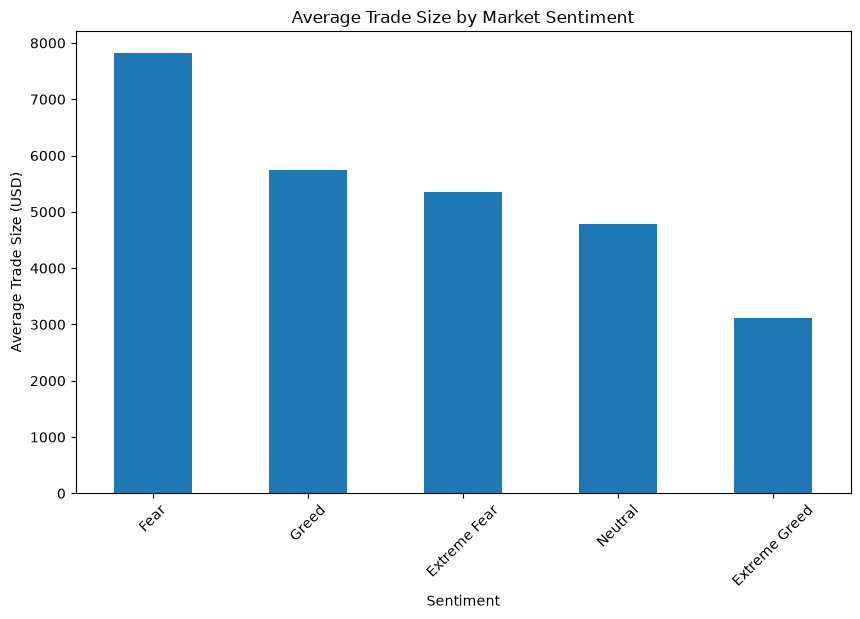

In [52]:
plt.figure(figsize=(10,6))

trade_size.plot(kind='bar')

plt.title('Average Trade Size by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Trade Size (USD)')
plt.xticks(rotation=45)

plt.show()

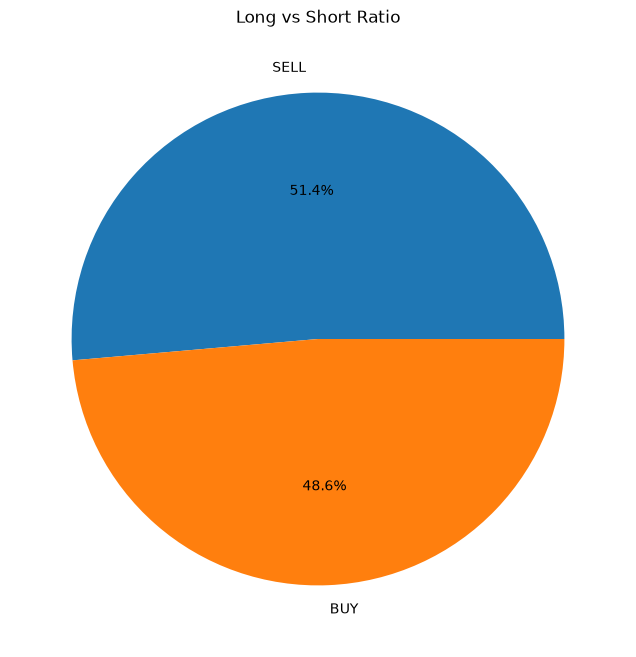

In [53]:
plt.figure(figsize=(8,8))

df['Side'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Long vs Short Ratio')
plt.ylabel('')

plt.show()

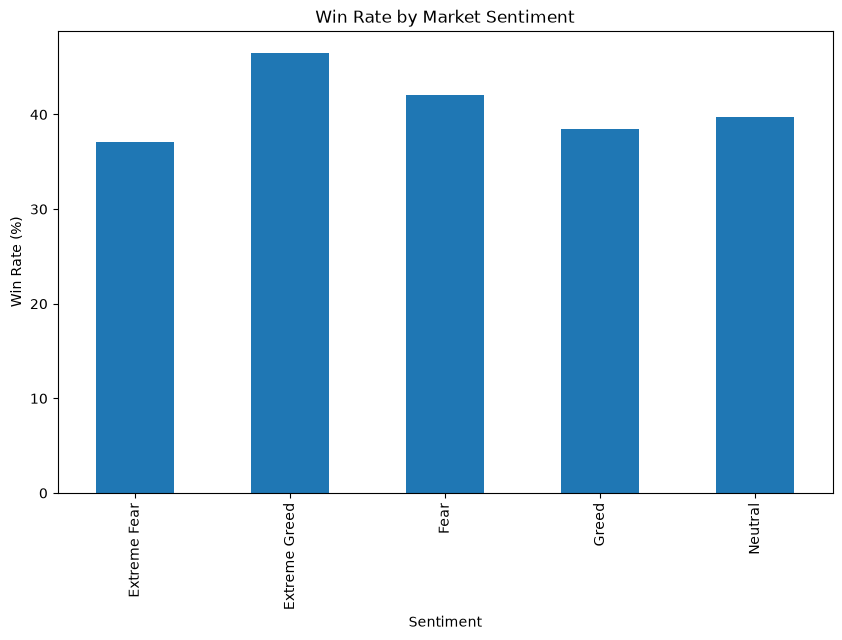

In [54]:
plt.figure(figsize=(10,6))

win_rate.plot(kind='bar')

plt.title('Win Rate by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Win Rate (%)')

plt.savefig('../charts/win_rate.png')
plt.show()

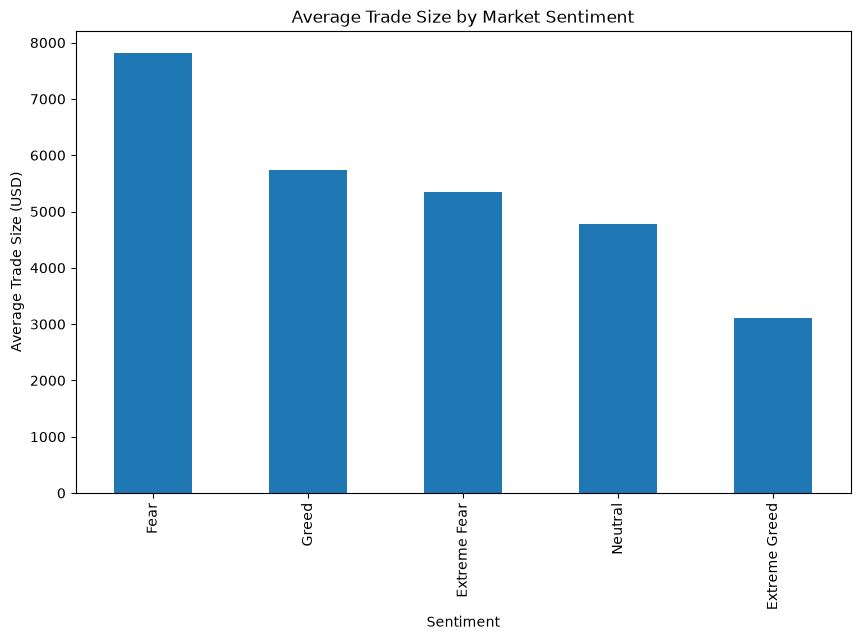

In [55]:
plt.figure(figsize=(10,6))

trade_size.plot(kind='bar')

plt.title('Average Trade Size by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Trade Size (USD)')

plt.savefig('../charts/trade_size.png')
plt.show()

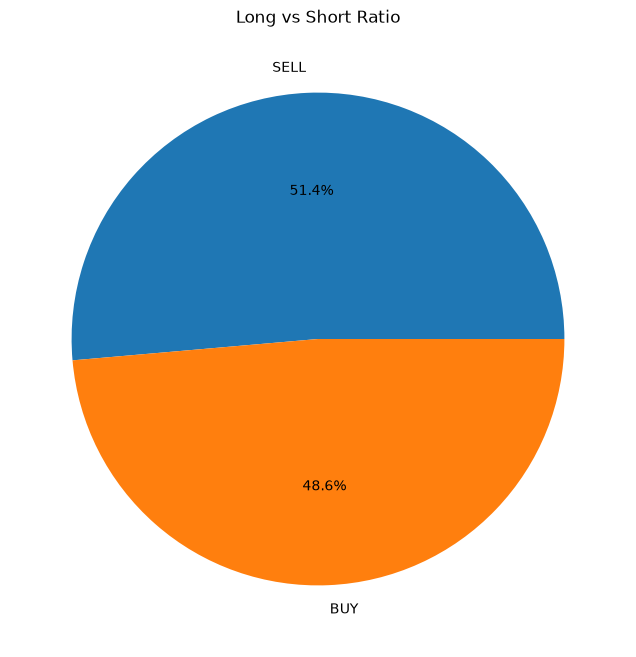

In [56]:
plt.figure(figsize=(8,8))

df['Side'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Long vs Short Ratio')
plt.ylabel('')

plt.savefig('../charts/long_short_ratio.png')
plt.show()